# Image Filter

In [55]:
import os
import shutil
from pathlib import Path

In [56]:
needed_article_ids = df_filtered['article_id'].unique()
needed_article_ids.shape

(5283,)

In [57]:
source_images_path = Path('../raw_data/images_256_256')
dest_images_path = Path('../raw_data/images_filtered')

In [58]:
copied_count = 0
missing_count = 0

for article_id in needed_article_ids:
    article_str = str(article_id).zfill(10)
    subfolder = article_str[:3]

    source_subfolder = source_images_path / subfolder
    dest_subfolder = dest_images_path / subfolder
    source_file = source_subfolder / f"{article_str}.jpg"
    dest_file = dest_subfolder / f"{article_str}.jpg"

    if source_file.exists():
        dest_subfolder.mkdir(exist_ok=True)

        shutil.copy2(source_file, dest_file)
        copied_count += 1
    else:
        missing_count += 1

print(f"Copied {copied_count} images")
print(f"Missing images: {missing_count}")
print(f"Total article IDs: {needed_article_ids.shape}")

Copied 5156 images
Missing images: 127
Total article IDs: (5283,)


In [59]:
list(df_filtered)

['article_id',
 'product_code',
 'prod_name',
 'product_type_no',
 'product_type_name',
 'product_group_name',
 'graphical_appearance_no',
 'graphical_appearance_name',
 'colour_group_code',
 'colour_group_name',
 'perceived_colour_value_id',
 'perceived_colour_value_name',
 'perceived_colour_master_id',
 'perceived_colour_master_name',
 'department_no',
 'department_name',
 'index_code',
 'index_name',
 'index_group_no',
 'index_group_name',
 'section_no',
 'section_name',
 'garment_group_no',
 'garment_group_name',
 'detail_desc']

# Subcategories exploration

### Check how many images per category:

In [72]:
df = pd.read_csv('../raw_data/articles_filtered.csv')
category_counts = df['product_type_name'].value_counts()

print("Images per category:")
print("=" * 50)
for category, count in category_counts.items():
    print(f"{category:20s}: {count:5d} images")
print("=" * 50)
print(f"TOTAL: {len(df)} images")

Images per category:
Sneakers            :  1573 images
Boots               :  1028 images
Sandals             :   733 images
Other shoe          :   383 images
Ballerinas          :   346 images
Slippers            :   244 images
Heeled sandals      :   200 images
Pumps               :   186 images
Flat shoe           :   159 images
Flip flop           :   123 images
Wedge               :   113 images
Bootie              :    31 images
Heels               :    22 images
Flat shoes          :    10 images
Moccasins           :     4 images
Pre-walkers         :     1 images
TOTAL: 5156 images


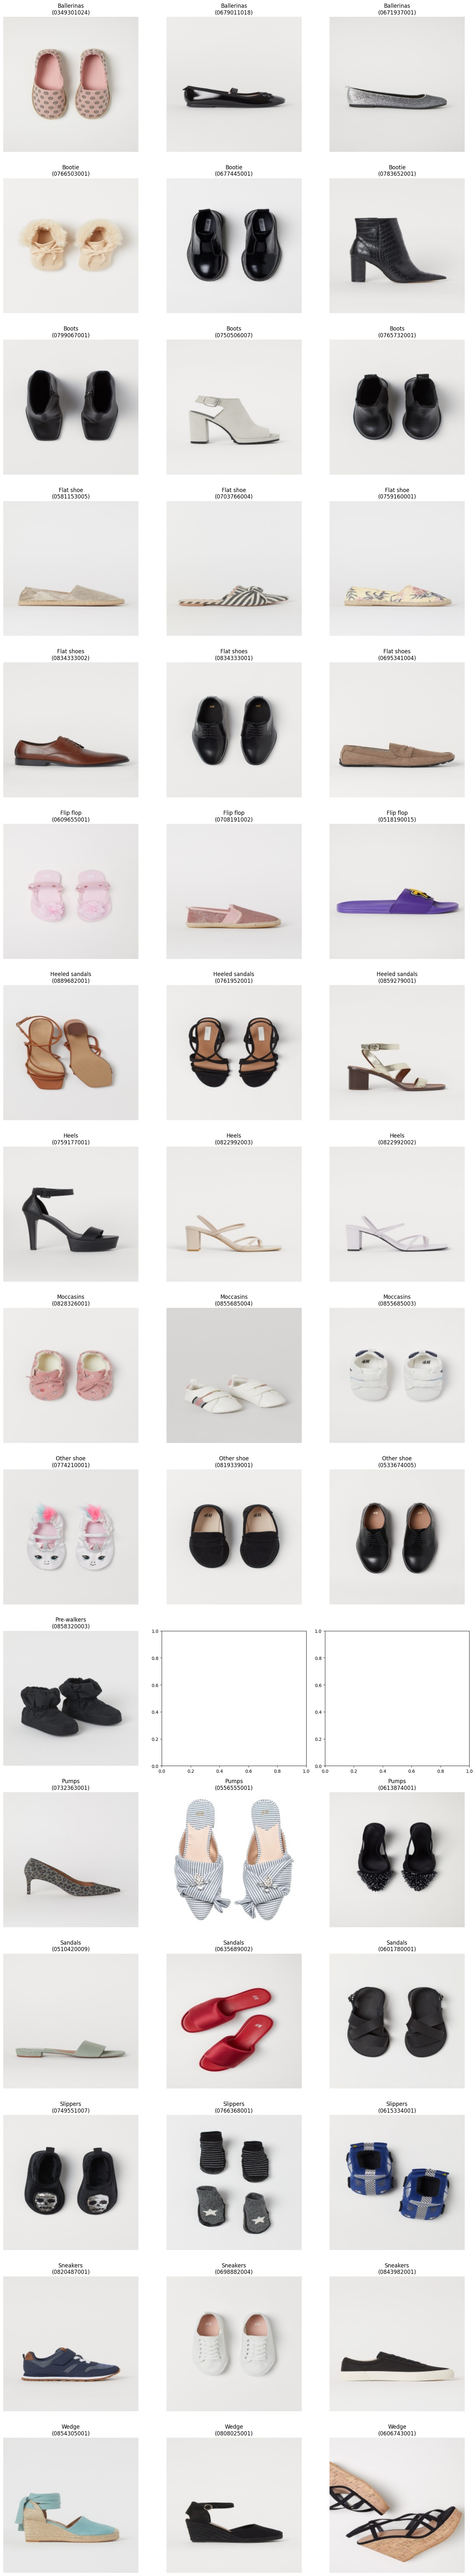

In [ ]:
import random
import pandas as pd
import matplotlib.pyplot as plt

categories_unique = df['product_type_name'].unique()

fig, axes = plt.subplots(len(categories_unique), 3, figsize=(15, 5*len(categories_unique)))

for i, category in enumerate(sorted(categories_unique)):
    category_articles = df[df['product_type_name'] == category]

    samples = category_articles.sample(min(3, len(category_articles)))

    for j, (idx, row) in enumerate(samples.iterrows()):
        article_id = str(row['article_id']).zfill(10)
        subfolder = article_id[:3]
        img_path = f"../raw_data/images_filtered/{subfolder}/{article_id}.jpg"

        try:
            img = Image.open(img_path)
            axes[i, j].imshow(img)
            axes[i, j].set_title(f"{category}\n({article_id})")
            axes[i, j].axis('off')
        except:
            axes[i, j].text(0.5, 0.5, 'Image\nNot Found',
                           ha='center', va='center')
            axes[i, j].axis('off')

plt.tight_layout()
plt.show()


Showing 10 examples from 'Other shoe' category


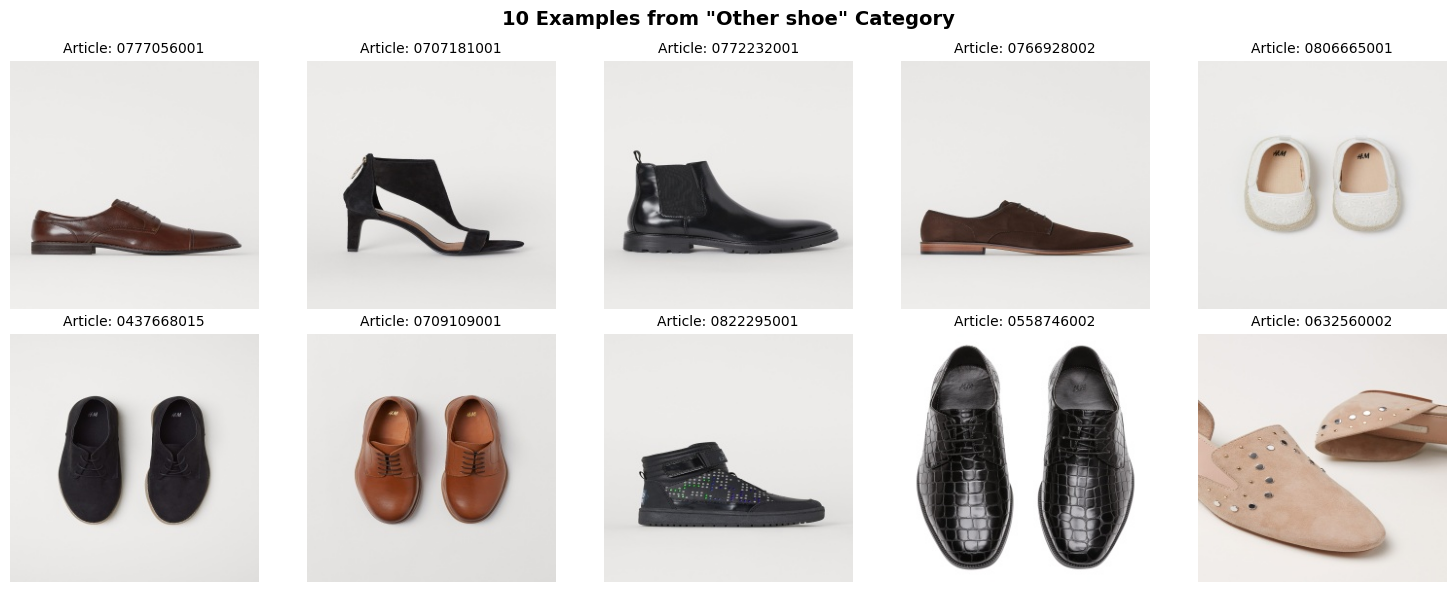

In [ ]:
print("\n" + "=" * 60)
print("Showing 10 examples from 'Other shoe' category")
print("=" * 60)

other_shoe_articles = df[df['product_type_name'] == 'Other shoe']
num_examples = min(10, len(other_shoe_articles))
samples = other_shoe_articles.sample(num_examples)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, (idx, row) in enumerate(samples.iterrows()):
    article_id = str(row['article_id']).zfill(10)
    subfolder = article_id[:3]
    img_path = f"../raw_data/images_filtered/{subfolder}/{article_id}.jpg"

    try:
        img = Image.open(img_path)
        axes[i].imshow(img)
        axes[i].set_title(f"Article: {article_id}", fontsize=10)
        axes[i].axis('off')
    except Exception as e:
        axes[i].text(0.5, 0.5, f'Image\nNot Found\n{article_id}',
                    ha='center', va='center')
        axes[i].axis('off')

plt.suptitle('10 Examples from "Other shoe" Category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()